# Phase 1 — Tailsitter Dynamics & Differential Flatness (walkthrough)

This notebook drives the **Phase 1** code: the phi-theory force/moment model, the
6-DOF simulator, and the differential-flatness transform that turns a flat output
`sigma = [x, psi]` (position + yaw) into attitude, body rates, and control inputs.

Everything tunable lives in `config/tailsitter.yaml`. Parameters flagged
`# ESTIMATE` there are geometry guesses (the paper does not publish the inertia
tensor, moment arms, `alpha0`, `alphaT`); swap in measured values to tighten the
match to the paper.

Replicates the machinery behind Tal-Ryou-Karaman (T-RO 2023).

## 0. Setup

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":   # run from repo root
    os.chdir("..")
import numpy as np
import matplotlib.pyplot as plt
from tailsitter.config import load_config
from tailsitter.dynamics.sim6dof import Tailsitter6DOF
from tailsitter.flatness.transform import FlatTransform
from tailsitter.utils.rotation import quat_to_euler_zxy

np.set_printoptions(precision=4, suppress=True)
cfg  = load_config()
sim  = Tailsitter6DOF(cfg)
flat = FlatTransform(cfg)
g, m = cfg.sim.g, cfg.vehicle.mass
print(f"mass {m} kg | span {cfg.vehicle.span} m | chord {cfg.vehicle.chord:.3f} m"
      f" | max rotor {cfg.vehicle.w_max} rad/s | max flap {cfg.vehicle.flap_max} rad")
print("inertia J =\n", cfg.vehicle.inertia)

mass 0.68 kg | span 0.55 m | chord 0.128 m | max rotor 2500.0 rad/s | max flap 1.0 rad
inertia J =
 [[0.0185 0.     0.    ]
 [0.     0.0012 0.    ]
 [0.     0.     0.0196]]


## 1. Hover trim

Feed the flatness transform a stationary request (`a = 0`, `v = 0`). It returns the
hover attitude, collective thrust, and the rotor/flap inputs that hold it. Total
thrust should be ~ `m*g`. Note the nonzero flap deflection: the thrust line offset
(`cmuT`) produces a pitch moment that the flaps trim out even in hover (the propwash
gives the flaps authority at zero airspeed).

In [2]:
att   = flat.attitude_thrust(np.zeros(3), psi=0.0, vel=np.zeros(3))
alloc = flat.allocate(att, np.zeros(3), np.zeros(3), np.zeros(3))
print(f"collective thrust T = {att['T']:.3f} N   (m*g = {m*g:.3f} N)")
print(f"pitch theta = {np.degrees(att['theta']):.1f} deg   (hover is ~ +90 deg, nose up)")
print(f"rotor speeds  w1={alloc['w1']:.0f}  w2={alloc['w2']:.0f} rad/s")
print(f"flap angles   d1={np.degrees(alloc['d1']):.1f}  d2={np.degrees(alloc['d2']):.1f} deg")

collective thrust T = 6.654 N   (m*g = 6.671 N)
pitch theta = 80.1 deg   (hover is ~ +90 deg, nose up)
rotor speeds  w1=1433  w2=1433 rad/s
flap angles   d1=-16.5  d2=-16.5 deg


## 2. Validation tests

These confirm the transform is correct. The **exact** identities (force/attitude
solve, roll+pitch moment allocation, angular-velocity kinematics) hold to machine
precision. Two **documented approximations** from the paper are quantified rather
than hidden:
* **A1** — the attitude solve neglects the direct (non-minimum-phase) flap force;
* **A2** — the allocation neglects the flap yaw moment (`~ sin(alpha0)`).

Both are closed by the INDI controller in Phase 3.

In [3]:
import importlib.util, sys, os
spec = importlib.util.spec_from_file_location("t1", os.path.join("tests","test_phase1.py"))
t1 = importlib.util.module_from_spec(spec); spec.loader.exec_module(t1)
_ = [t1.test_hover(), t1.test_reconstruction(), t1.test_omega_kinematics()]

T0  Hover trim (a=0, v=0)
     T=6.654 N (mg=6.671)  theta=80.1 deg  w=1433,1433 rad/s  delta=-0.287,-0.287 rad
  [PASS] angular accel == 0 (exact)                       = 2.313e-14  (tol 1e-10)
  [PASS] vdot == neglected flap-force term (A1 exact)     = 1.554e-15  (tol 1e-10)
  [info] approximation A1 gap |vdot| [m/s^2]              = 3.495e+00
T1  Reconstruction along a 6 m/s coordinated circle


  [PASS] force/attitude reconstruction (Eqs 20-26 exact)  = 7.229e-15  (tol 1e-10)
  [PASS] roll+pitch moment reconstruction (exact)         = 1.422e-16  (tol 1e-09)
  [info] approximation A2 gap, yaw moment [N m]           = 1.137e-03
T2  Numeric Omega is consistent with attitude kinematics


  [PASS] integrate(xi_dot) matches next attitude          = 7.813e-12  (tol 1e-05)


## 3. The flatness transform along a trajectory

Define a smooth flat output (a coordinated 6 m/s circle) and push it through the
transform to recover attitude, body rate, and the control inputs the vehicle would
need to fly it. This is exactly the pipeline Phase 2 uses to check feasibility.

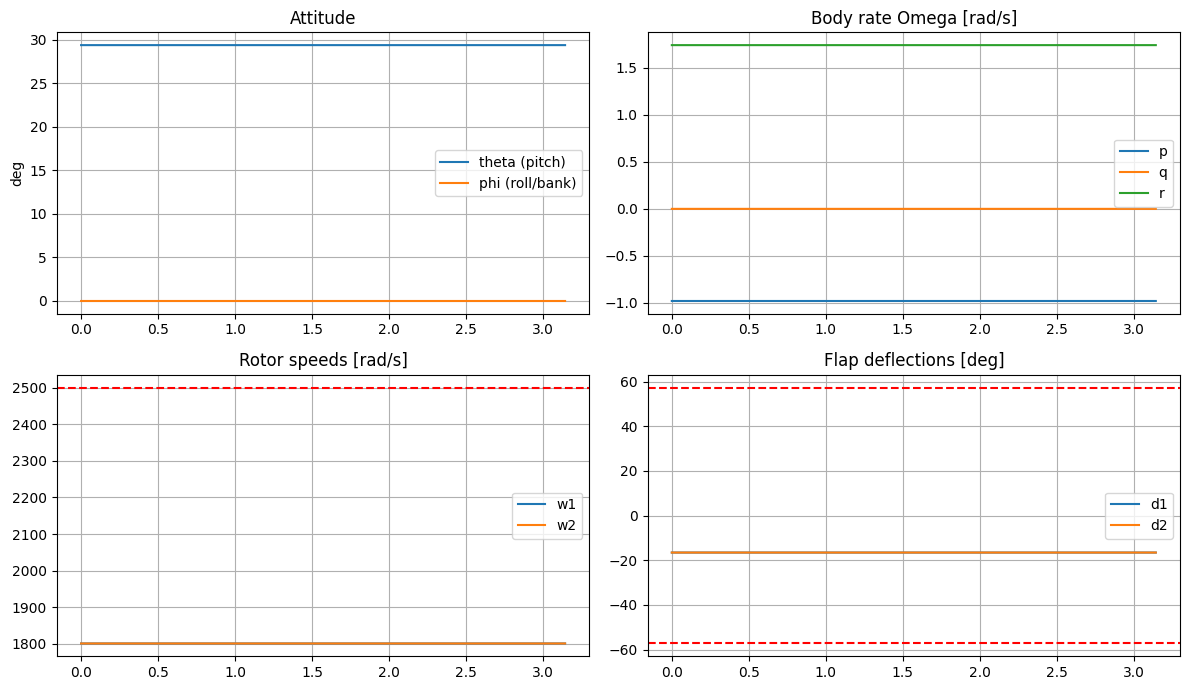

all samples feasible: True


In [4]:
def circle(r=3.0, speed=6.0, h=2.0, mode="coordinated"):
    w = speed / r
    def traj(t):
        c, s = np.cos(w*t), np.sin(w*t)
        pos = np.array([r*c, r*s, -h])
        vel = np.array([-r*w*s, r*w*c, 0.0])
        acc = np.array([-r*w*w*c, -r*w*w*s, 0.0])
        head = np.arctan2(vel[1], vel[0])
        psi  = head + (np.pi/2 if mode == "coordinated" else 0.0)
        return pos, vel, acc, psi
    return traj, 2*np.pi*r/speed   # also return one period

traj, period = circle(speed=6.0, mode="coordinated")
ts  = np.linspace(0, period, 2001)
ref = flat.reference(traj, ts)

eul = np.array([quat_to_euler_zxy(q) for q in ref['q']])   # psi, phi, theta
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].plot(ts, np.degrees(eul[:,2]), label='theta (pitch)')
ax[0,0].plot(ts, np.degrees(eul[:,1]), label='phi (roll/bank)')
ax[0,0].set_ylabel('deg'); ax[0,0].set_title('Attitude'); ax[0,0].legend(); ax[0,0].grid()
ax[0,1].plot(ts, ref['Omega']); ax[0,1].set_title('Body rate Omega [rad/s]')
ax[0,1].legend(['p','q','r']); ax[0,1].grid()
ax[1,0].plot(ts, ref['w1'], label='w1'); ax[1,0].plot(ts, ref['w2'], label='w2')
ax[1,0].axhline(cfg.vehicle.w_max, ls='--', c='r'); ax[1,0].set_title('Rotor speeds [rad/s]')
ax[1,0].legend(); ax[1,0].grid()
ax[1,1].plot(ts, np.degrees(ref['d1']), label='d1'); ax[1,1].plot(ts, np.degrees(ref['d2']), label='d2')
ax[1,1].axhline(np.degrees(cfg.vehicle.flap_max), ls='--', c='r')
ax[1,1].axhline(np.degrees(cfg.vehicle.flap_min), ls='--', c='r')
ax[1,1].set_title('Flap deflections [deg]'); ax[1,1].legend(); ax[1,1].grid()
plt.tight_layout(); plt.savefig('plots/circle_reference.png', dpi=110); plt.show()
print('all samples feasible:', bool(ref['feasible'].all()))

## 4. Feasibility envelope (open-loop, the cheap evaluation)

The paper's key trick: feasibility is just the flatness transform run open-loop. Push
a candidate trajectory through it, read off the implied rotor speeds and flap angles,
and if they exceed the limits the trajectory is infeasible — **no integration needed**.
Here we sweep the speed of a circular trajectory for coordinated vs knife-edge flight
and find where each hits the actuator limits (the idea behind the paper's Fig. 7 / 10).

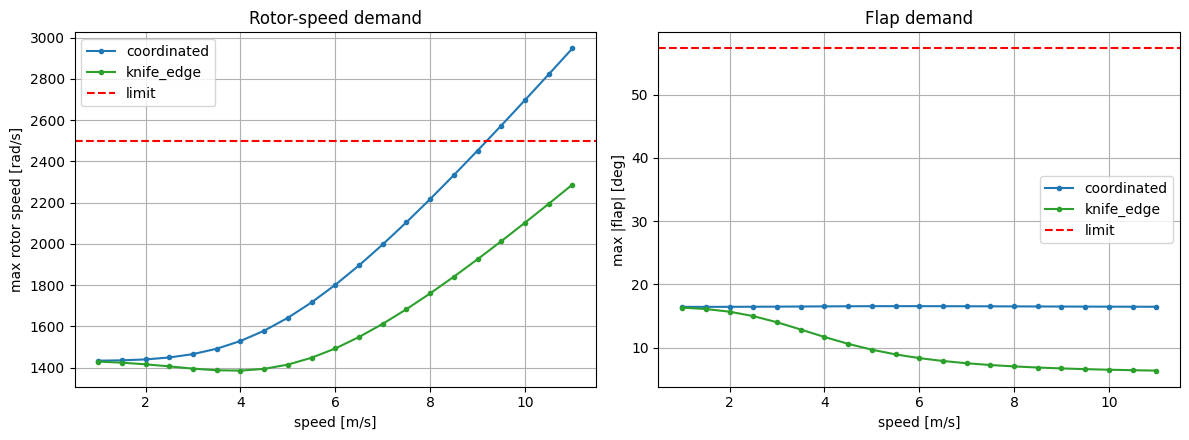

Where a curve crosses its red limit line = the feasibility boundary for that mode.


In [5]:
def max_demand(speed, mode, r=3.0):
    traj, period = circle(r=r, speed=speed, mode=mode)
    ts = np.linspace(0, period, 601)
    ref = flat.reference(traj, ts)
    # ignore gradient endpoints
    sl = slice(20, -20)
    return (np.nanmax(np.maximum(ref['w1'][sl], ref['w2'][sl])),
            np.nanmax(np.abs(np.concatenate([ref['d1'][sl], ref['d2'][sl]]))))

speeds = np.linspace(1.0, 11.0, 21)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for mode, col in [("coordinated", "tab:blue"), ("knife_edge", "tab:green")]:
    wmax = []; dmax = []
    for v in speeds:
        try:
            w, d = max_demand(v, mode)
        except Exception:
            w, d = np.nan, np.nan
        wmax.append(w); dmax.append(d)
    ax[0].plot(speeds, wmax, '-o', ms=3, color=col, label=mode)
    ax[1].plot(speeds, np.degrees(dmax), '-o', ms=3, color=col, label=mode)
ax[0].axhline(cfg.vehicle.w_max, ls='--', c='r', label='limit')
ax[0].set_xlabel('speed [m/s]'); ax[0].set_ylabel('max rotor speed [rad/s]')
ax[0].set_title('Rotor-speed demand'); ax[0].legend(); ax[0].grid()
ax[1].axhline(np.degrees(cfg.vehicle.flap_max), ls='--', c='r', label='limit')
ax[1].set_xlabel('speed [m/s]'); ax[1].set_ylabel('max |flap| [deg]')
ax[1].set_title('Flap demand'); ax[1].legend(); ax[1].grid()
plt.tight_layout(); plt.savefig('plots/feasibility_envelope.png', dpi=110); plt.show()
print('Where a curve crosses its red limit line = the feasibility boundary for that mode.')

## 5. Open-loop is unstable (this is why Phase 3 needs a controller)

The tailsitter is open-loop unstable. Holding the hover inputs constant with no
feedback, the vehicle tips over within a fraction of a second — exactly why the paper
wraps the flatness transform inside an **INDI feedback controller** (Phase 3). The
feasibility check above does *not* need the controller; closed-loop *tracking* does.

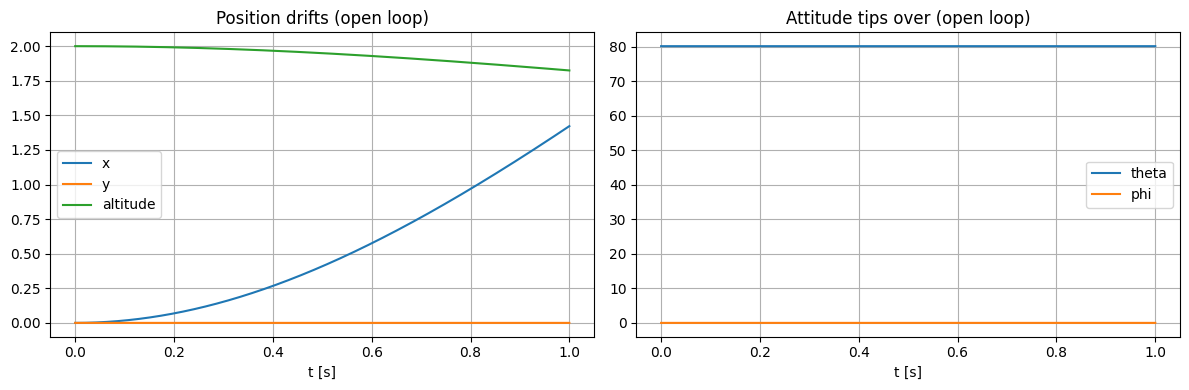

Open-loop divergence is expected and correct. Phase 3 adds the INDI loop.


In [6]:
u_hover = np.array([alloc['w1'], alloc['w2'], alloc['d1'], alloc['d2']])
x0 = np.zeros(13); x0[2] = -2.0; x0[6:10] = att['q']
ts2, xs = sim.rollout(x0, lambda t: u_hover, T=1.0)
eul2 = np.array([quat_to_euler_zxy(q) for q in xs[:, 6:10]])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ts2, xs[:, 0], label='x'); ax[0].plot(ts2, xs[:, 1], label='y')
ax[0].plot(ts2, -xs[:, 2], label='altitude'); ax[0].set_xlabel('t [s]')
ax[0].set_title('Position drifts (open loop)'); ax[0].legend(); ax[0].grid()
ax[1].plot(ts2, np.degrees(eul2[:, 2]), label='theta')
ax[1].plot(ts2, np.degrees(eul2[:, 1]), label='phi')
ax[1].set_xlabel('t [s]'); ax[1].set_title('Attitude tips over (open loop)')
ax[1].legend(); ax[1].grid()
plt.tight_layout(); plt.savefig('plots/openloop_instability.png', dpi=110); plt.show()
print('Open-loop divergence is expected and correct. Phase 3 adds the INDI loop.')

## What Phase 1 gives you / what's next

**You now have, tested:** the phi-theory dynamics, a 6-DOF simulator, and a validated
differential-flatness transform that maps any smooth `sigma(t)` to attitude, body rate,
and rotor/flap inputs — plus an open-loop feasibility check.

**Phase 2** reuses the MIT-AERA minimum-snap generator (their `BaseTrajFunc` /
`MinSnapTrajectory`) to build smooth `sigma(t)` from waypoints, swaps their quadrotor
feasibility model for `FlatTransform.reference` above, and adds time-optimal scaling —
reproducing the paper's aerobatic reference trajectories and feasibility-boundary plots.